In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Solving a 1D diffusion equation with the Euler forward method

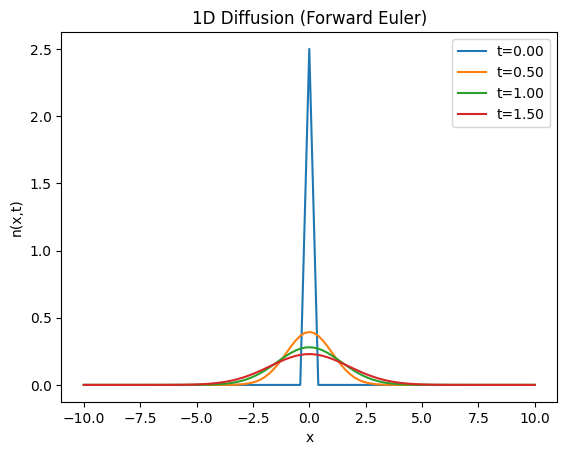

In [2]:
# -----------------------
# Parameters
# -----------------------
L = 10.0          # domain size [-L,L]
Nx = 101          # number of spatial points
dx = 2*L / (Nx-1)
x = np.linspace(-L, L, Nx)

D = 1.0           # diffusion coefficient
dt = 0.01         # time step (must satisfy stability!)
Nt = 200          # number of time steps

# Stability condition: dt <= dx^2 / (2D)
if dt > dx**2/(2*D):
    print("Warning: dt too large, may be unstable!")

# -----------------------
# Initial condition: delta-like peak at center
# -----------------------
n = np.zeros(Nx)
# Injection at the center
n[Nx//2] = 1.0 / dx  # approximate delta function -- Divides Nx by 2 rounding down to the nearest integer (floor)

# -----------------------
# Time stepping (Forward Euler)
# -----------------------
for t in range(Nt):
    n_new = np.copy(n)
    # update interior points
    for i in range(1, Nx-1):
        n_new[i] = n[i] + D*dt/dx**2 * (n[i+1] - 2*n[i] + n[i-1])
    n = n_new

    #Better: Vectorized form    
    #for t in range(Nt):
    #    n[1:-1] += D*dt/dx**2 * (n[2:] - 2*n[1:-1] + n[:-2])

    
    # Important note: What happens at the edges of your grid depends on the boundary conditions. 
    # You may prefer Dirichlet (fixed) or Newmann (zero flux) (periodic boundaries make no sense for us)
    n[0] = 0
    n[-1] = 0

    
    # plot every 50 steps
    if t % 50 == 0:
        plt.plot(x, n, label=f"t={t*dt:.2f}")
        


# -----------------------
# Final plot
# -----------------------
plt.xlabel("x")
plt.ylabel("n(x,t)")
plt.title("1D Diffusion (Forward Euler)")
plt.legend()
plt.show()

### Including now injection and a loss term to reach a steady-state solution

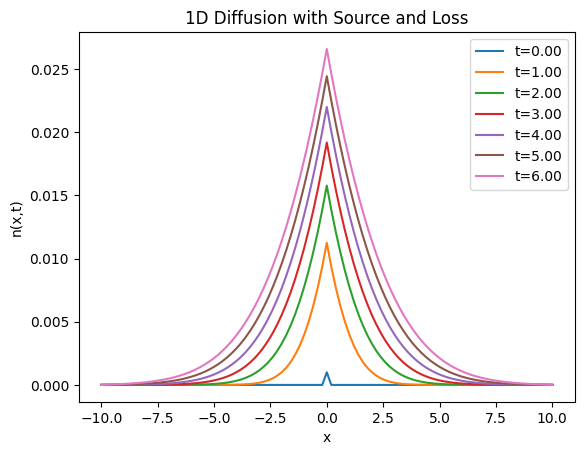

In [5]:
# -----------------------
# Parameters
# -----------------------
L = 10.0
Nx = 101
dx = 2*L / (Nx-1)
x = np.linspace(-L, L, Nx)

D = 1.0
dt = 0.01
Nt = 700

tau = 50.0       # loss timescale
#tau = 2      
Q0 = 0.1         # constant source amplitude

# Stability condition for explicit Euler
if dt > dx**2/(2*D):
    print("Warning: dt too large, may be unstable!")

# -----------------------
# Initial condition: zero everywhere
# -----------------------
n = np.zeros(Nx)

# Our source is injecting particles only at the center
source_index = Nx//2

# -----------------------
# Time stepping (vectorized)
# -----------------------
for t in range(Nt):
    n_new = np.copy(n)
    
    # diffusion term (interior points)
    n_new[1:-1] = n[1:-1] + D*dt/dx**2 * (n[2:] - 2*n[1:-1] + n[:-2])
    
    # add source term
    n_new[source_index] += Q0 * dt
    
    # add loss term
    n_new[1:-1] -= dt * n[1:-1] / tau
    
    # update
    n = n_new
    
    # plot every 100 steps
    if t % 100 == 0:
        plt.plot(x, n, label=f"t={t*dt:.2f}")

# -----------------------
# Final plot
# -----------------------
plt.xlabel("x")
plt.ylabel("n(x,t)")
plt.title("1D Diffusion with Source and Loss")
plt.legend()
plt.show()

#Important note: Over long times, the system reaches a steady state where diffusion spreads particles, the source adds them, and the loss removes them.

## Solving a 1D diffusion equation with the Crank-Nicolson method

In [107]:
# -----------------------
# Parameters
# -----------------------
L = 10.0
Nx = 101                    # total grid points
dx = 2*L / (Nx-1)
x = np.linspace(-L, L, Nx)

D = 1.0
dt = 0.05                    # can be larger than explicit Euler
Nt = 200                     # number of timesteps

# -----------------------
# Crank-Nicolson coefficient
# -----------------------
a = D * dt / (2 * dx**2)

# Number of interior points (exclude boundaries)
Nx_int = Nx - 2



# -----------------------
# Construct tridiagonal matrices
# -----------------------
# Matrix A (implicit part)
main_diag_A = (1 + 2*a) * np.ones(Nx_int)
off_diag_A  = -a * np.ones(Nx_int - 1)
A = np.diag(main_diag_A) + np.diag(off_diag_A, 1) + np.diag(off_diag_A, -1)

# Matrix B (explicit part)
main_diag_B = (1 - 2*a) * np.ones(Nx_int)
off_diag_B  = a * np.ones(Nx_int - 1)
B = np.diag(main_diag_B) + np.diag(off_diag_B, 1) + np.diag(off_diag_B, -1)

# -----------------------
# Initial condition: delta at center
# -----------------------
n = np.zeros(Nx)
n[Nx//2] = 1.0 / dx         # delta-like peak at center


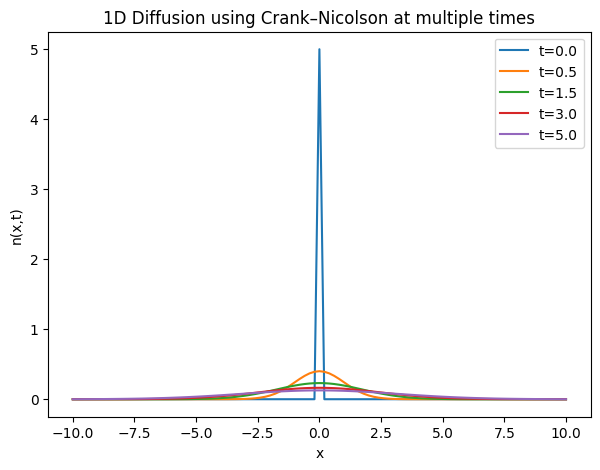

In [108]:
# -----------------------
# Prepare to store multiple times
# -----------------------
times_to_plot = [0, 10, 30, 60, 100]  # timesteps we want to plot
n_history = []  # list to store densities

# -----------------------
# Time stepping
# -----------------------
for t in range(Nt+1):
    # Store if this timestep is in times_to_plot
    if t in times_to_plot:
        n_history.append(n.copy())
    
    # Skip update on last timestep
    if t == Nt:
        break
    
    rhs = B @ n[1:-1]
    n[1:-1] = np.linalg.solve(A, rhs)

# -----------------------
# Plot all selected times
# -----------------------
plt.figure(figsize=(7,5))
for idx, n_snapshot in zip(times_to_plot, n_history):
    plt.plot(x, n_snapshot, label=f't={idx*dt:.1f}')
plt.xlabel('x')
plt.ylabel('n(x,t)')
plt.title('1D Diffusion using Crank–Nicolson at multiple times')
plt.legend()
plt.show()

### Crank–Nicolson a closer look on how to solve the inverse of a matrix: 
`n[1:-1] = np.linalg.solve(A, rhs)`


---

Crank–Nicolson gives a **linear system** for the interior points of \(n\) at the next time step:

$A \, n^{n+1}_\text{interior} = \text{RHS}$

Where:

- \(A\) is the **tridiagonal matrix** representing the implicit diffusion part.
- `RHS` is a vector representing the explicit contributions from the previous time step \(n^n\) and boundary conditions.

So mathematically:

$n^{n+1}_1, n^{n+1}_2, \dots, n^{n+1}_{Nx-2} = A^{-1} \cdot \text{RHS}$

---

#### What `np.linalg.solve(A, rhs)` does

- Solves the linear system:

\[
A \, x = b
\]

- Returns the solution vector `x`, which are the **new interior values** at the next time step.
- This is more efficient and numerically stable than computing the matrix inverse.

One could also have done:
  x = np.linalg.inv(A) @ rhs

---


**Compute RHS**: combines old values `n^n` and boundary contributions.
   
   ```python
   rhs = B @ n[1:-1] + boundary_terms